<a href="https://colab.research.google.com/github/Shah4l/deep-learning-projects/blob/main/CNN_2_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [ ]:
print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
classes={0:'airplane',1:'automobile',2:'bird',3:'cat',4:'deer',5:'dog',6:'frog',7:'horse',8:'ship',9:'truck'}

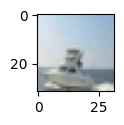

In [ ]:
plt.figure(figsize=(1,1))
plt.imshow(x_train[100])

In [ ]:
int(y_train[100])

/tmp/ipython-input-2001451441.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  int(y_train[100])


8

In [ ]:
classes[int(y_train[100])]

/tmp/ipython-input-2253872502.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  classes[int(y_train[100])]


'ship'

In [ ]:
model=Sequential()
model.add(Conv2D(20,(3,3),activation='relu',input_shape=(32,32,3),padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='SparseCategoricalCrossentropy',optimizer=Adam(),metrics=['accuracy'])

In [ ]:
trained_history=model.fit(x_train,y_train,batch_size=500,epochs=20,validation_data=(x_test,y_test))

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 521ms/step - accuracy: 0.1001 - loss: 9.0538 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 535ms/step - accuracy: 0.0986 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 517ms/step - accuracy: 0.0985 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 508ms/step - accuracy: 0.1000 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 506ms/step - accuracy: 0.0985 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 84s 531ms/step - accuracy: 0.0963 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 540ms/step - accuracy: 0.0970 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 540ms/step - accuracy: 0.0961 - loss: 2

In [ ]:
hist=trained_history.history
hist.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

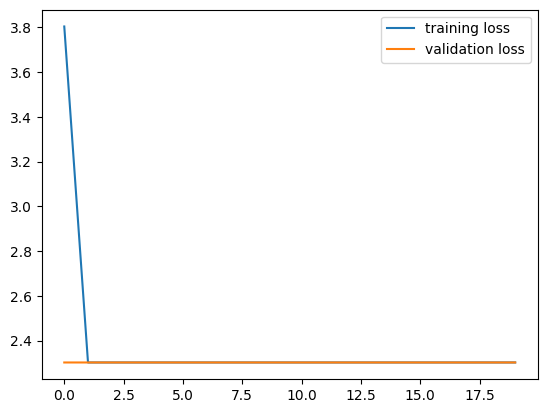

In [ ]:
plt.plot(hist['loss'],label='training loss')
plt.plot(hist['val_loss'],label='validation loss')
plt.legend()

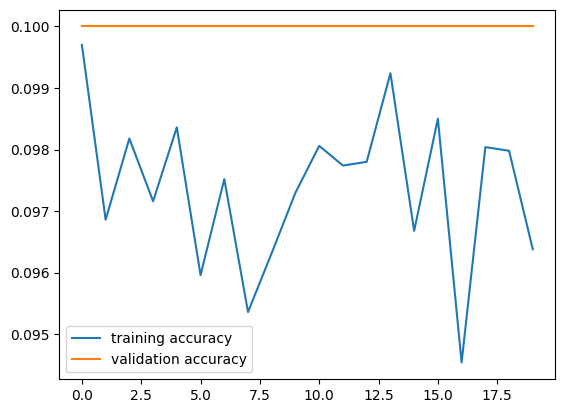

In [ ]:
plt.plot(hist['accuracy'],label='training accuracy')
plt.plot(hist['val_accuracy'],label='validation accuracy')
plt.legend()

In [ ]:
loss,accuracy=model.evaluate(x_test,y_test,verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.0987 - loss: 2.3026


In [ ]:
import numpy as np
def predict(index):
  plt.imshow(x_test[index])
  pred_image=x_test[index].reshape(1,32,32,3)
  pred_prob=model.predict(pred_image)
  pred_class=np.argmax(pred_prob,axis=1)
  pred_label=classes[int(pred_class)]
  print('Original label:',classes[int(y_test[index])])
  print('Predictrd label:',pred_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Original label: horse
Predictrd label: deer


/tmp/ipython-input-2115200662.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label=classes[int(pred_class)]
/tmp/ipython-input-2115200662.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Original label:',classes[int(y_test[index])])


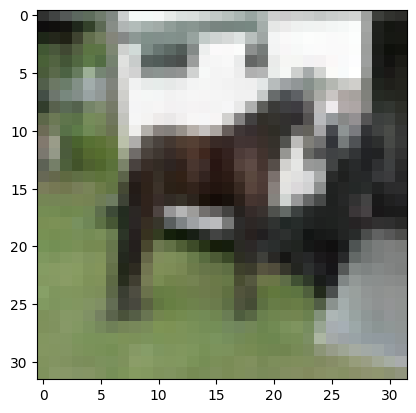

In [ ]:
predict(20)